In [3]:
import os

os.chdir(r"D:\Projects\expernetic-airbnb-assessment")

print(os.getcwd())

D:\Projects\expernetic-airbnb-assessment


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Makes charts appear inside the notebook
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_csv("data/processed/listings_clean.csv")

# Analysis 1: Distribution of Airbnb Room Types

## Business Question

What types of accommodation are most commonly listed on Airbnb?

## Objective

Understand the composition of Airbnb listings by room type to identify which accommodation category dominates the market.

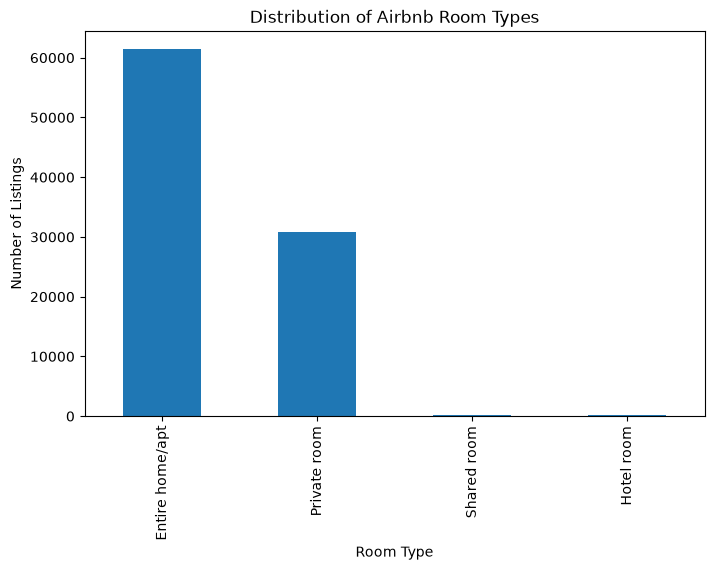

In [31]:
room_counts = df["room_type"].value_counts()

plt.figure(figsize=(8,5))

room_counts.plot(kind="bar")

plt.title("Distribution of Airbnb Room Types")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")

plt.show()

## Observation

- Entire homes/apartments account for the largest number of listings.
- Private rooms are the second most common accommodation type.
- Shared rooms and hotel rooms represent only a very small proportion of the market.

## Business Interpretation

The Airbnb market is primarily composed of entire homes and apartments, indicating that guests generally prefer private accommodation over shared spaces. This insight suggests that property owners offering complete homes have greater market presence and may benefit from higher customer demand.

# Analysis 2: Distribution of Listing Prices

## Business Question

How are Airbnb listing prices distributed?

## Objective

Examine the pricing distribution to understand the overall pricing structure of the market and identify the presence of high-priced or low-priced listings.

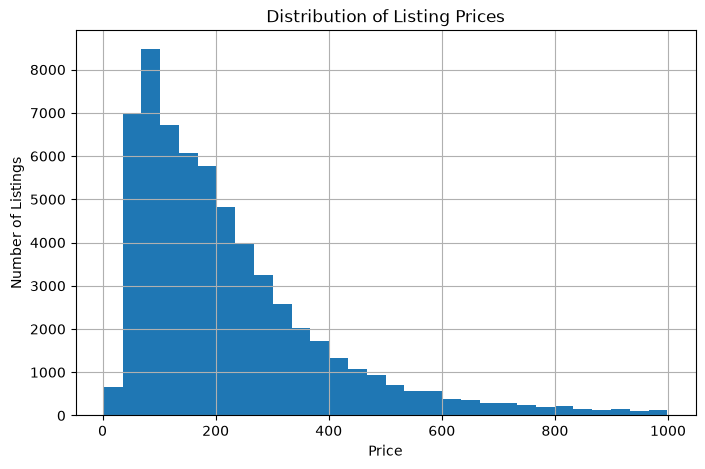

In [17]:
plt.figure(figsize=(8,5))

df["price"].hist(
    bins=30
)

plt.title("Distribution of Listing Prices")

plt.xlabel("Price")

plt.ylabel("Number of Listings")

plt.show()

## Observation

- Most listings fall within the lower-to-middle price range.
- Only a relatively small number of listings are priced at very high values.
- The distribution is positively (right) skewed.

## Business Interpretation

Most Airbnb properties target budget and mid-range travelers, while only a small proportion of luxury listings exist. The presence of a right-skewed distribution suggests that premium properties increase the overall average price even though they represent a minority of listings.

# Analysis 3: Top 10 Property Types

## Business Question

Which property types are most commonly listed?

## Objective

Identify the dominant property categories available on the Airbnb platform.

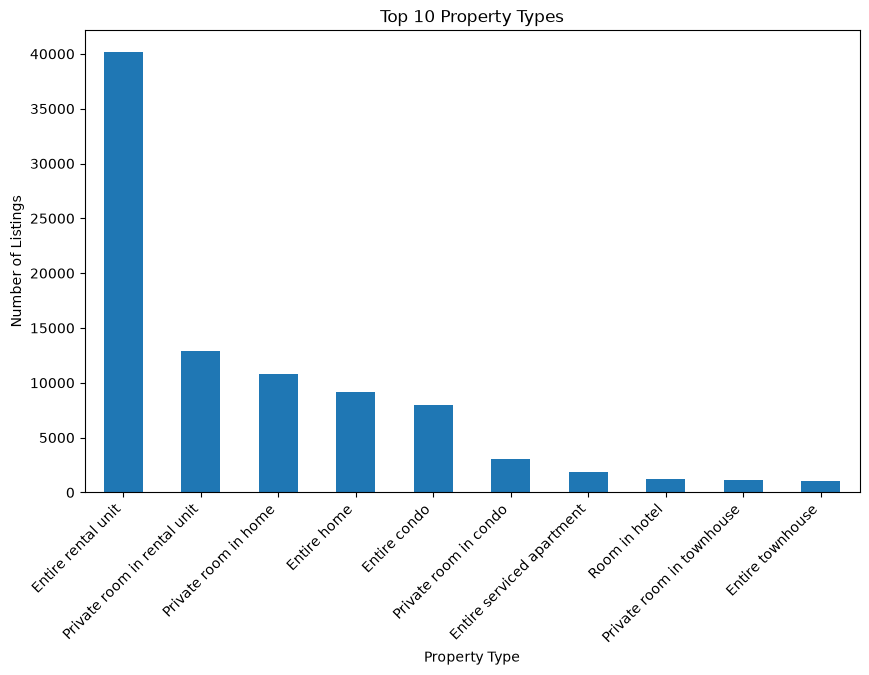

In [26]:
property_counts = (
    df["property_type"]
      .value_counts()
      .head(10)
)

plt.figure(figsize=(10,6))

property_counts.plot(kind="bar")

plt.title("Top 10 Property Types")

plt.xlabel("Property Type")

plt.ylabel("Number of Listings")

plt.xticks(rotation=45, ha="right")

plt.show()

## Observation

- Entire rental units represent the largest category.
- Private rooms in rental units and private rooms in homes are also common.
- Several other accommodation types have considerably fewer listings.

## Business Interpretation

The Airbnb marketplace is dominated by apartment-style accommodation. This reflects the urban nature of the selected city and indicates that apartments are the preferred property type for both hosts and guests.

# Analysis 4: Average Price by Room Type

## Business Question

Which room type has the highest average listing price?

## Objective

Compare the average prices of different room types to understand how accommodation type influences pricing.

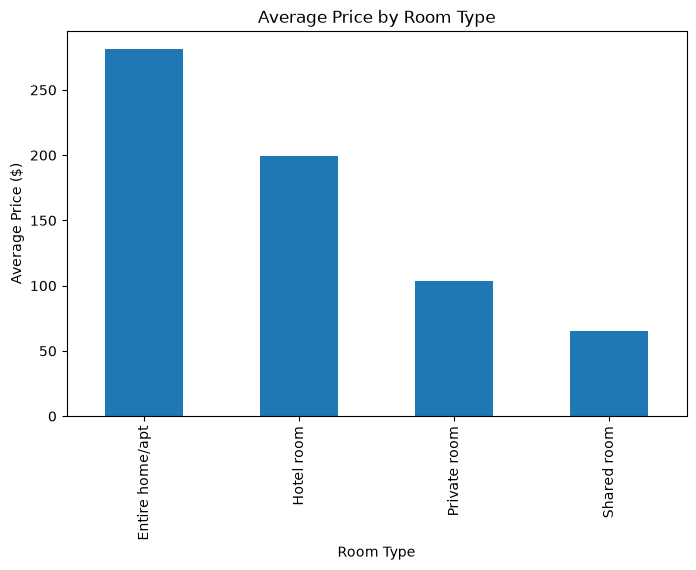

In [ ]:
avg_price = (
    df.groupby("room_type")["price"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

avg_price.plot(kind="bar")

plt.title("Average Price by Room Type")

plt.xlabel("Room Type")

plt.ylabel("Average Price ($)")

plt.show()

## Observation

- Entire homes have the highest average price.
- Hotel rooms also command relatively high prices.
- Private rooms are generally more affordable.
- Shared rooms have the lowest average price.

## Business Interpretation

Entire homes generate the highest average revenue per booking because guests pay for exclusive use of the entire property. Budget-conscious travelers are more likely to choose private or shared rooms, resulting in lower average prices for these accommodation types.

# Analysis 5: Average Price by Neighbourhood

## Business Question

Which neighbourhoods have the highest average Airbnb prices?

## Objective

Identify premium neighbourhoods where Airbnb properties command the highest prices.

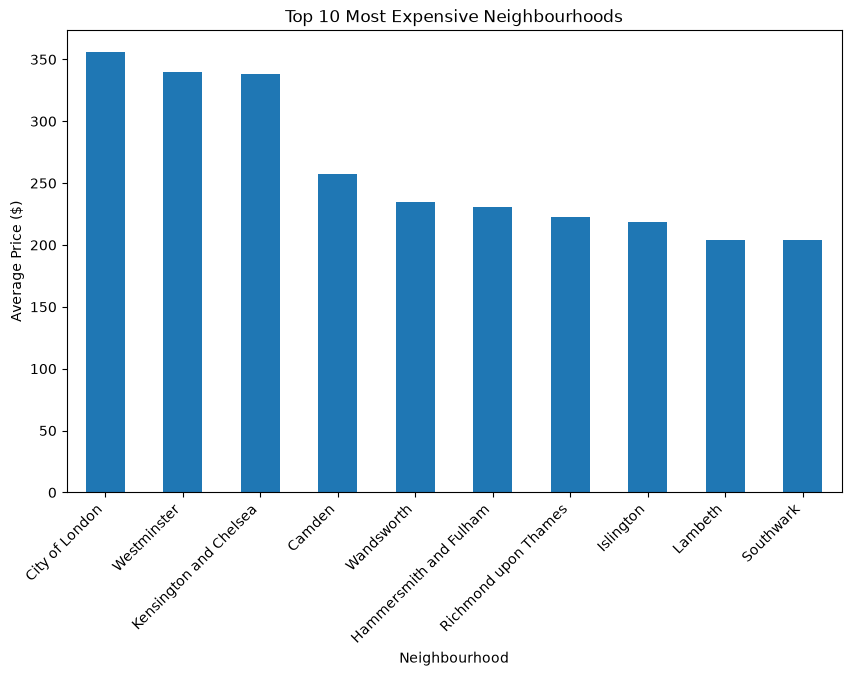

In [30]:
top_neighbourhoods = (
    df.groupby("neighbourhood_cleansed")["price"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

top_neighbourhoods.plot(kind="bar")

plt.title("Top 10 Most Expensive Neighbourhoods")

plt.xlabel("Neighbourhood")

plt.ylabel("Average Price ($)")

plt.xticks(rotation=45, ha="right")

plt.show()

## Observation

- A small number of neighbourhoods have significantly higher average prices than the rest.
- Price differences between neighbourhoods are substantial.
- Premium locations consistently command higher prices.

## Business Interpretation

Location has a strong influence on Airbnb pricing. Properties located in premium neighbourhoods can charge considerably higher prices, suggesting that geographical location is one of the key factors affecting listing value.

# Analysis 6: Superhost vs Non-Superhost Pricing

## Business Question

Do Superhosts charge higher prices than non-Superhosts?

## Objective

Compare the average listing prices of Superhosts and non-Superhosts to determine whether Superhost status is associated with higher pricing.

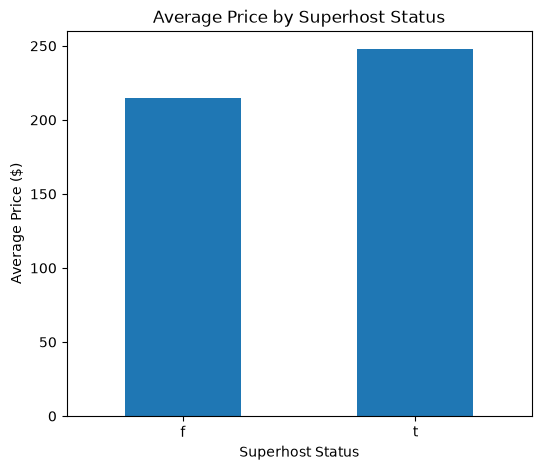

In [38]:
superhost_price = (
    df.groupby("host_is_superhost")["price"]
      .mean()
)

plt.figure(figsize=(6,5))

superhost_price.plot(kind="bar")

plt.title("Average Price by Superhost Status")
plt.xlabel("Superhost Status")
plt.ylabel("Average Price ($)")

plt.xticks(rotation=0)

plt.show()

## Observation

- Superhosts have a higher average listing price than non-Superhosts.
- Non-Superhosts represent the lower average price category.
- The difference suggests a positive relationship between Superhost status and listing price.

## Business Interpretation

Superhosts appear to command higher average prices than non-Superhosts. This may indicate that guests are willing to pay more for experienced hosts with strong reputations, consistent service quality, and positive guest experiences.

## Conclusion

Superhost status appears to provide a pricing advantage. Maintaining excellent hosting standards may enable hosts to charge higher nightly rates while remaining competitive in the Airbnb marketplace.

# Analysis 7: Review Score vs Listing Price

## Business Question

Is there a relationship between review ratings and listing prices?

## Objective

Investigate whether listings with higher review scores tend to have higher prices.

In [ ]:
corr = df[[
    "price",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "review_scores_rating"
]].corr()

corr

,price,accommodates,bedrooms,beds,bathrooms,number_of_reviews,review_scores_rating
price,1.000000,0.586533,0.455185,0.457052,0.398772,-0.092468,0.053344
accommodates,0.586533,1.000000,0.764835,0.829398,0.515039,-0.050995,-0.027852
bedrooms,0.455185,0.764835,1.000000,0.771860,0.678477,-0.045780,0.040886
beds,0.457052,0.829398,0.771860,1.000000,0.532921,-0.053835,-0.016599
bathrooms,0.398772,0.515039,0.678477,0.532921,1.000000,-0.050573,0.025425
number_of_reviews,-0.092468,-0.050995,-0.045780,-0.053835,-0.050573,1.000000,0.071691
review_scores_rating,0.053344,-0.027852,0.040886,-0.016599,0.025425,0.071691,1.000000


# Analysis 6: Superhost vs Non-Superhost Pricing

## Business Question

Do Superhosts charge higher prices than non-Superhosts?

## Objective

Compare the average listing prices of Superhosts and non-Superhosts to determine whether Superhost status is associated with higher pricing.

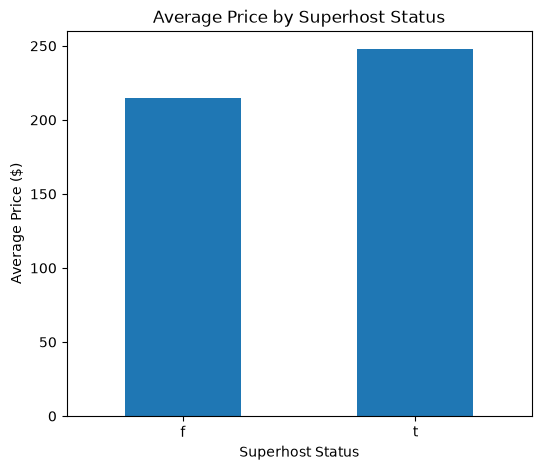

In [33]:
superhost_price = (
    df.groupby("host_is_superhost")["price"]
      .mean()
)

plt.figure(figsize=(6,5))

superhost_price.plot(kind="bar")

plt.title("Average Price by Superhost Status")

plt.xlabel("Superhost Status")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=0)

plt.show()

# Analysis 7: Review Score vs Price

## Business Question

Is there a relationship between review ratings and listing prices?

## Objective

Investigate whether listings with higher review scores tend to have higher prices.

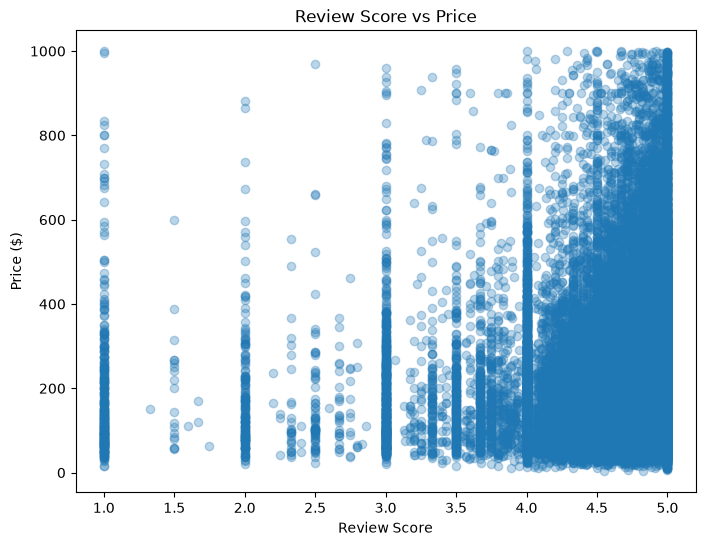

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["review_scores_rating"],
    df["price"],
    alpha=0.3
)

plt.title("Review Score vs Price")

plt.xlabel("Review Score")

plt.ylabel("Price ($)")

plt.show()

## Observation

- Listings with review scores between 4.5 and 5.0 dominate the dataset.
- Both low-priced and high-priced listings receive high review scores.
- No clear linear relationship is visible between review score and listing price.

## Business Interpretation

Higher customer ratings do not necessarily correspond to higher listing prices. Although positive reviews are valuable for building trust, pricing appears to be influenced more strongly by factors such as property size, location, and accommodation capacity.

## Conclusion

Review ratings alone are not strong predictors of listing price. Airbnb hosts should focus on both service quality and property characteristics to maximize pricing potential.

# Analysis 8: Correlation Analysis

## Business Question

Which property characteristics have the strongest relationship with listing price?

## Objective

Measure the relationships between price and selected numerical variables using a correlation matrix.

In [37]:
corr = df[[
    "price",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "review_scores_rating"
]].corr()

corr

,price,accommodates,bedrooms,beds,bathrooms,number_of_reviews,review_scores_rating
price,1.000000,0.586533,0.455185,0.457052,0.398772,-0.092468,0.053344
accommodates,0.586533,1.000000,0.764835,0.829398,0.515039,-0.050995,-0.027852
bedrooms,0.455185,0.764835,1.000000,0.771860,0.678477,-0.045780,0.040886
beds,0.457052,0.829398,0.771860,1.000000,0.532921,-0.053835,-0.016599
bathrooms,0.398772,0.515039,0.678477,0.532921,1.000000,-0.050573,0.025425
number_of_reviews,-0.092468,-0.050995,-0.045780,-0.053835,-0.050573,1.000000,0.071691
review_scores_rating,0.053344,-0.027852,0.040886,-0.016599,0.025425,0.071691,1.000000


## Observation

- Accommodation capacity shows the strongest positive correlation with price (0.587).
- Bedrooms, beds, and bathrooms also have moderate positive correlations with price.
- Review scores have a very weak positive correlation with price.
- Number of reviews has a very weak negative correlation with price.

## Business Interpretation

Property size and capacity have a much greater influence on listing price than customer ratings. Hosts with larger properties are generally able to charge higher prices, while review-related variables contribute relatively little to pricing decisions.

## Conclusion

The analysis indicates that physical property characteristics are the primary drivers of Airbnb pricing. Customer reviews contribute to guest confidence but have only a limited relationship with the listed price.

# Analysis 9: Price Outlier Detection

## Business Question

Are there unusually expensive Airbnb listings that differ significantly from the majority of the market?

## Objective

Identify price outliers using a boxplot to better understand the distribution of listing prices.

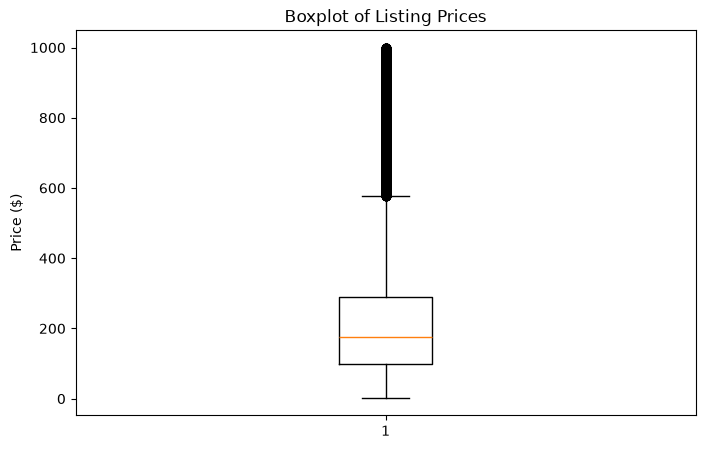

In [36]:
plt.figure(figsize=(8,5))

plt.boxplot(df["price"].dropna())

plt.title("Boxplot of Listing Prices")

plt.ylabel("Price ($)")

plt.show()

## Observation

- Most listings fall within a moderate price range.
- A large number of observations appear above the upper whisker.
- Several listings are priced substantially higher than the majority of properties.

## Business Interpretation

The Airbnb market contains a relatively small number of premium or luxury properties that command significantly higher prices than typical listings. These high-value properties increase the average price and should be considered when interpreting summary statistics.

## Conclusion

The presence of numerous high-price outliers indicates that the market contains both standard and luxury accommodation segments. Median values are likely to provide a more representative measure of central tendency than the mean for this dataset.